In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import scipy.stats as stats
import numpy as np


In [2]:
df = pd.read_excel('koalas_dataset.xlsx')

In [3]:
df.head(15)

,koala_id,region,habitat,gender,age_in_years,Paw Size,total_length,head_length,ear_size,foot_length,skull_width,eye_diameter,chest_circumference,belly_circumference
0,1,1,VIC,m,8.0,16.0,77.0,19.1,19.5,24.5,15.4,2.2,63.0,61.0
1,2,1,VIC,f,6.0,16.5,79.5,17.5,16.2,22.5,12.6,3.0,63.5,58.0
2,3,1,VIC,f,6.0,19.0,83.5,19.0,16.9,25.4,15.0,2.5,65.0,59.0
3,4,1,VIC,f,6.0,18.0,80.0,18.2,17.2,26.1,12.1,2.2,63.0,59.0
4,5,1,VIC,f,2.0,16.0,73.5,16.5,18.2,21.0,11.3,2.1,63.5,58.0
5,6,1,VIC,f,1.0,15.5,78.5,18.1,18.6,23.2,9.8,1.2,65.0,57.0
6,7,1,VIC,m,2.0,16.0,77.5,20.3,17.0,21.5,13.2,1.2,65.0,59.5
7,8,1,VIC,f,6.0,17.0,79.0,19.8,18.9,22.7,12.6,1.5,64.0,59.0
8,9,1,VIC,f,9.0,17.0,79.5,18.4,17.9,22.4,11.3,2.5,63.0,58.0
9,10,1,VIC,f,6.0,17.5,77.5,16.8,18.4,20.9,13.0,1.4,62.5,57.0


## Checking details regarding data types and size of the database ##

In [8]:
size = len(df)
print('The length of the database is', size)

The length of the database is 104


In [10]:
data_types = df.dtypes
print(data_types)

koala_id                 int64
region                   int64
habitat                 object
gender                  object
age_in_years           float64
Paw Size               float64
total_length           float64
head_length            float64
ear_size               float64
foot_length            float64
skull_width            float64
eye_diameter           float64
chest_circumference    float64
belly_circumference    float64
dtype: object


## Checking and clearing the null values in each column ##

In [13]:
null_values_per_column = df.isnull().sum()
print(null_values_per_column)

koala_id               0
region                 0
habitat                0
gender                 0
age_in_years           2
Paw Size               0
total_length           0
head_length            0
ear_size               0
foot_length            2
skull_width            1
eye_diameter           0
chest_circumference    0
belly_circumference    1
dtype: int64


In [15]:
clean_df1 = df.dropna()

null_values_after = clean_df1.isnull().sum()
print(null_values_after)

koala_id               0
region                 0
habitat                0
gender                 0
age_in_years           0
Paw Size               0
total_length           0
head_length            0
ear_size               0
foot_length            0
skull_width            0
eye_diameter           0
chest_circumference    0
belly_circumference    0
dtype: int64


In [17]:
print("The length of the database after cleaning null values is", len(clean_df1))

The length of the database after cleaning null values is 98


### Fixing descriptive data of the dataset ###

In [20]:
unique_region = clean_df1['region'].value_counts()
print(unique_region)

region
1    33
7    17
5    12
6    12
2    10
3     7
4     7
Name: count, dtype: int64


In [22]:
unique_habitat = clean_df1['habitat'].value_counts()
print(unique_habitat)

habitat
QLD           51
VIC           41
VICtoria       1
Vic            1
Queensland     1
Queenstown     1
qld            1
q              1
Name: count, dtype: int64


In [24]:
clean_df1['habitat'] = clean_df1['habitat'].str.upper()

clean_df1['habitat'] = clean_df1['habitat'].replace({'QUEENSLAND': 'QLD','Q': 'QLD','QLD': 'QLD', 'QUEENSTOWN': 'QLD', 'VICTORIA': 'VIC','VIC': 'VIC', 'V': 'VIC'})

unique_habitat = clean_df1['habitat'].value_counts()
print(unique_habitat)

habitat
QLD    55
VIC    43
Name: count, dtype: int64


/var/folders/g4/skmbbm9j1v9c18bdym6wyxvc0000gn/T/ipykernel_79833/597019086.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df1['habitat'] = clean_df1['habitat'].str.upper()
/var/folders/g4/skmbbm9j1v9c18bdym6wyxvc0000gn/T/ipykernel_79833/597019086.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df1['habitat'] = clean_df1['habitat'].replace({'QUEENSLAND': 'QLD','Q': 'QLD','QLD': 'QLD', 'QUEENSTOWN': 'QLD', 'VICTORIA': 'VIC','VIC': 'VIC', 'V': 'VIC'})


In [26]:
unique_gender = clean_df1['gender'].value_counts()
print(unique_gender)

gender
m         56
f         40
female     1
male       1
Name: count, dtype: int64


In [28]:
clean_df1['gender'] = clean_df1['gender'].replace({'m': 'Male','male': 'Male','f': 'Female', 'female': 'Female'})

unique_gender = clean_df1['gender'].value_counts()
print(unique_gender)

gender
Male      57
Female    41
Name: count, dtype: int64


/var/folders/g4/skmbbm9j1v9c18bdym6wyxvc0000gn/T/ipykernel_79833/1337728042.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df1['gender'] = clean_df1['gender'].replace({'m': 'Male','male': 'Male','f': 'Female', 'female': 'Female'})


## Identifying and Removing Outliers ##

### Removing outliers from the age column ###

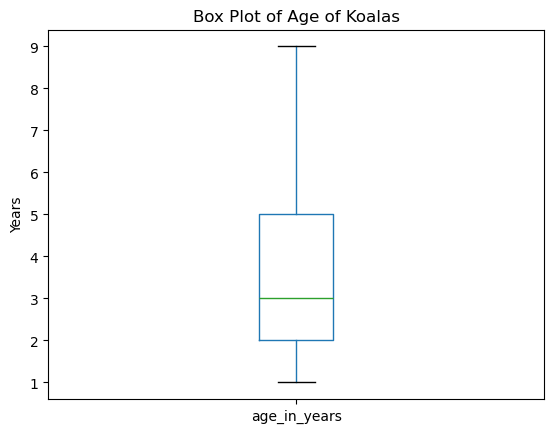

In [32]:
clean_df1.boxplot(column='age_in_years')

plt.grid(False)
plt.title('Box Plot of Age of Koalas')
plt.ylabel('Years')
plt.show()

### Removing outliers from the paw size column ###

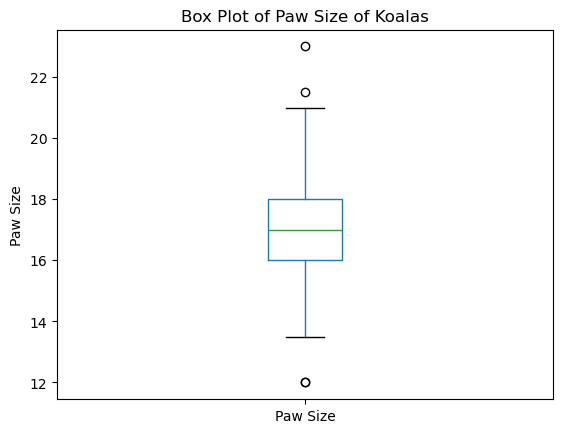

In [35]:
clean_df1.boxplot(column='Paw Size')

plt.grid(False)
plt.title('Box Plot of Paw Size of Koalas')
plt.ylabel('Paw Size')
plt.show()

In [37]:
Q1 = clean_df1['Paw Size'].quantile(0.25)
Q3 = clean_df1['Paw Size'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

clean_df1 = clean_df1[(clean_df1['Paw Size'] >= lower_bound) & (clean_df1['Paw Size'] <= upper_bound)]

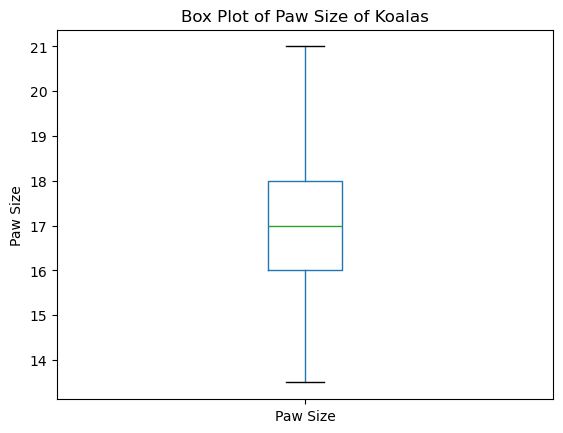

In [39]:
clean_df1.boxplot(column='Paw Size')

plt.grid(False)
plt.title('Box Plot of Paw Size of Koalas')
plt.ylabel('Paw Size')
plt.show()

### Removing outliers from the total length column ###

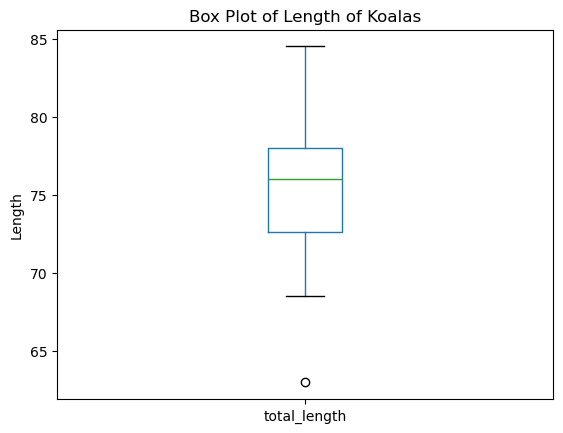

In [42]:
clean_df1.boxplot(column='total_length')

plt.grid(False)
plt.title('Box Plot of Length of Koalas')
plt.ylabel('Length')
plt.show()

In [44]:
Q1 = clean_df1['total_length'].quantile(0.25)
Q3 = clean_df1['total_length'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

clean_df1 = clean_df1[(clean_df1['total_length'] >= lower_bound) & (clean_df1['total_length'] <= upper_bound)]

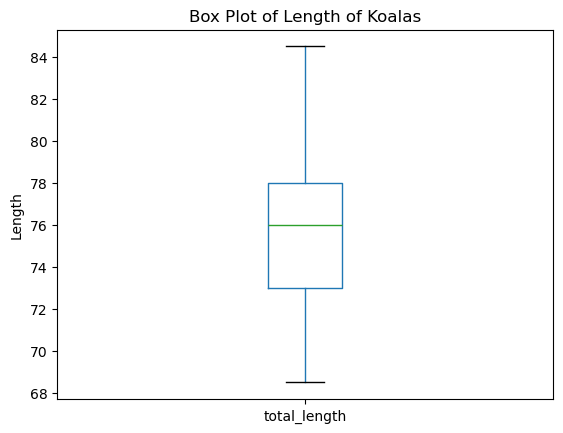

In [46]:
clean_df1.boxplot(column='total_length')

plt.grid(False)
plt.title('Box Plot of Length of Koalas')
plt.ylabel('Length')
plt.show()

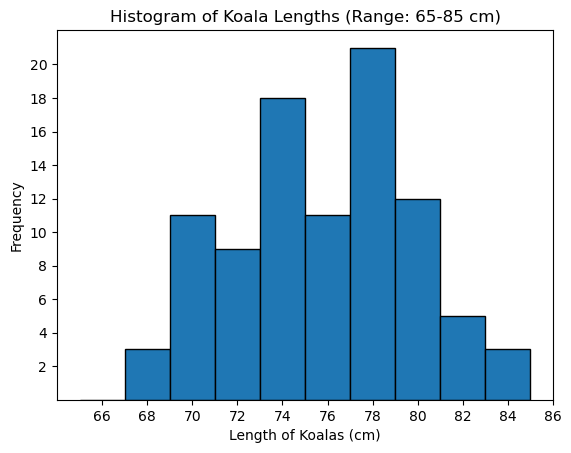

In [48]:
koala_lengths = clean_df1['total_length']

plt.hist(koala_lengths, bins=10, range=(65, 85), edgecolor='black')

plt.xlabel('Length of Koalas (cm)')
plt.ylabel('Frequency')
plt.title('Histogram of Koala Lengths (Range: 65-85 cm)')
plt.yticks([2, 4, 6, 8, 10, 12, 14, 16, 18, 20])
plt.xticks([66,68,70,72,74,76,78,80,82,84,86])

plt.show()


In [50]:
clean_df1 = clean_df1[clean_df1['total_length'] <= 82]

### Cleaning the Head Length Column ###

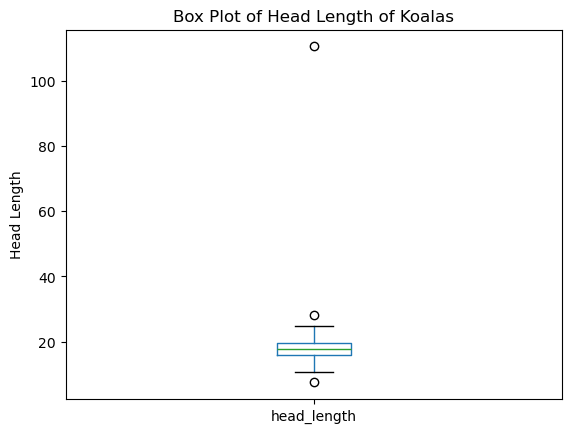

In [53]:
clean_df1.boxplot(column='head_length')

plt.grid(False)
plt.title('Box Plot of Head Length of Koalas')
plt.ylabel('Head Length')
plt.show()

In [55]:
Q1 = clean_df1['head_length'].quantile(0.25)
Q3 = clean_df1['head_length'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

clean_df1 = clean_df1[(clean_df1['head_length'] >= lower_bound) & (clean_df1['head_length'] <= upper_bound)]

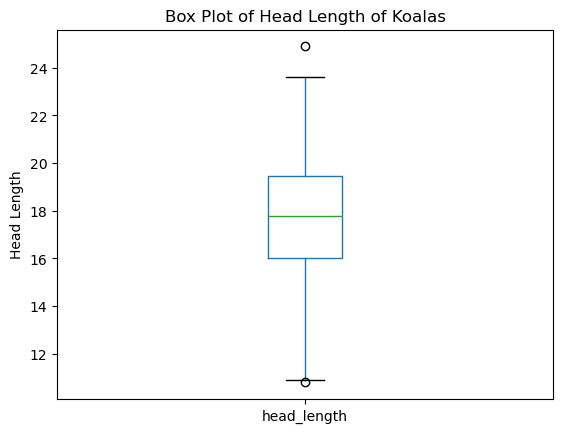

In [57]:
clean_df1.boxplot(column='head_length')

plt.grid(False)
plt.title('Box Plot of Head Length of Koalas')
plt.ylabel('Head Length')
plt.show()

### Cleaning the Ear Size column ###

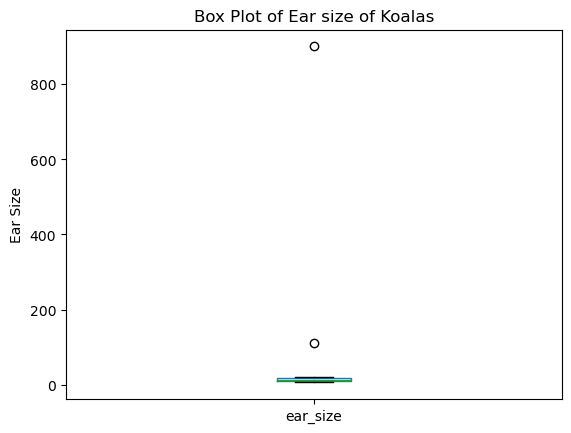

In [60]:
clean_df1.boxplot(column='ear_size')

plt.grid(False)
plt.title('Box Plot of Ear size of Koalas')
plt.ylabel('Ear Size')
plt.show()

In [62]:
Q1 = clean_df1['ear_size'].quantile(0.25)
Q3 = clean_df1['ear_size'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

clean_df1 = clean_df1[(clean_df1['ear_size'] >= lower_bound) & (clean_df1['ear_size'] <= upper_bound)]

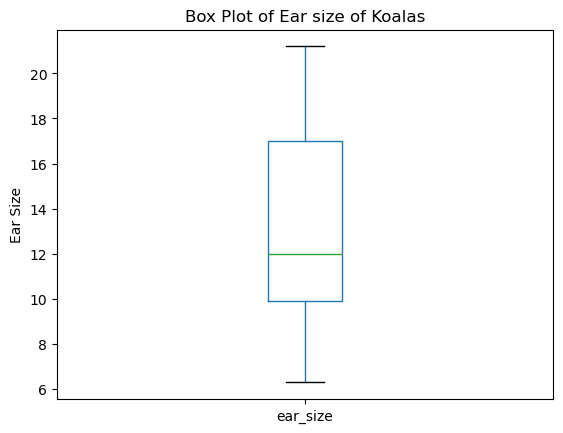

In [64]:
clean_df1.boxplot(column='ear_size')

plt.grid(False)
plt.title('Box Plot of Ear size of Koalas')
plt.ylabel('Ear Size')
plt.show()

### Cleaning the Foot Length Column ###

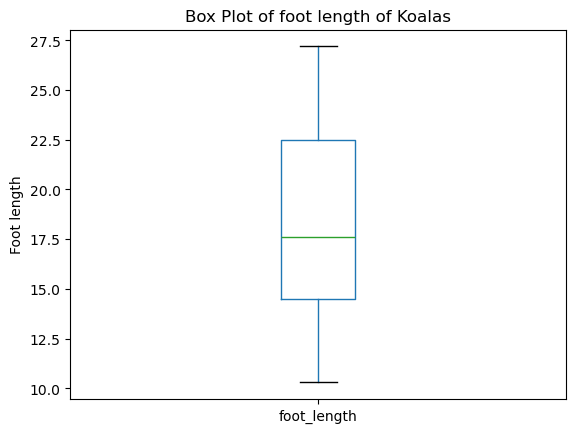

In [67]:
clean_df1.boxplot(column='foot_length')

plt.grid(False)
plt.title('Box Plot of foot length of Koalas')
plt.ylabel('Foot length')
plt.show()

### Cleaning the skull width column ###

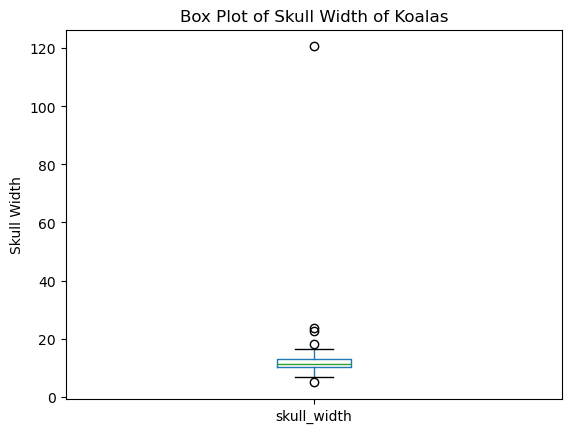

In [70]:
clean_df1.boxplot(column='skull_width')

plt.grid(False)
plt.title('Box Plot of Skull Width of Koalas')
plt.ylabel('Skull Width')
plt.show()

In [72]:
Q1 = clean_df1['skull_width'].quantile(0.25)
Q3 = clean_df1['skull_width'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

clean_df1 = clean_df1[(clean_df1['skull_width'] >= lower_bound) & (clean_df1['skull_width'] <= upper_bound)]

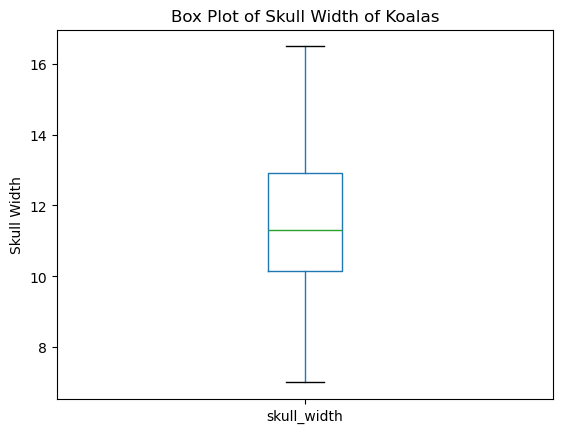

In [74]:
clean_df1.boxplot(column='skull_width')

plt.grid(False)
plt.title('Box Plot of Skull Width of Koalas')
plt.ylabel('Skull Width')
plt.show()

### Cleaning the Eye Diameter Column ###

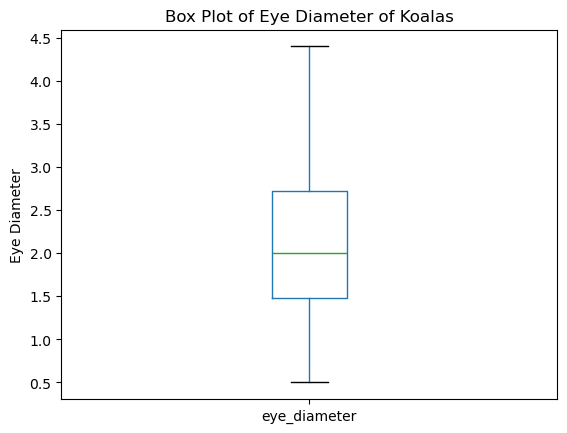

In [77]:
clean_df1.boxplot(column='eye_diameter')

plt.grid(False)
plt.title('Box Plot of Eye Diameter of Koalas')
plt.ylabel('Eye Diameter')
plt.show()

In [79]:
Q1 = clean_df1['eye_diameter'].quantile(0.25)
Q3 = clean_df1['eye_diameter'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

clean_df1 = clean_df1[(clean_df1['eye_diameter'] >= lower_bound) & (clean_df1['eye_diameter'] <= upper_bound)]

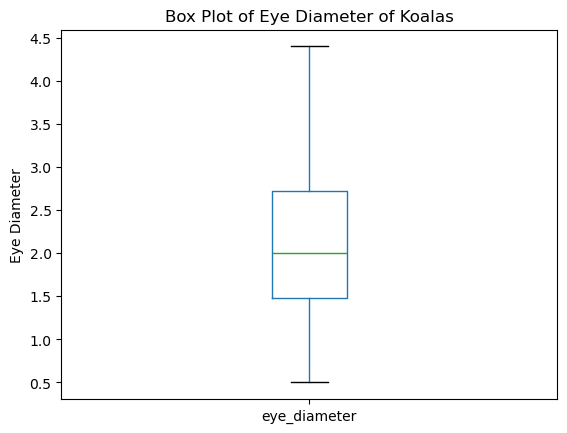

In [81]:
clean_df1.boxplot(column='eye_diameter')

plt.grid(False)
plt.title('Box Plot of Eye Diameter of Koalas')
plt.ylabel('Eye Diameter')
plt.show()

### Cleaning the Chest Circumference column ###

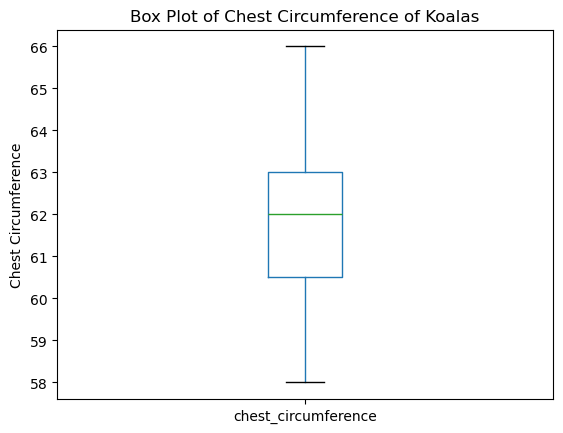

In [84]:
clean_df1.boxplot(column='chest_circumference')

plt.grid(False)
plt.title('Box Plot of Chest Circumference of Koalas')
plt.ylabel('Chest Circumference')
plt.show()

### Cleaning the Belly Circumference column ###

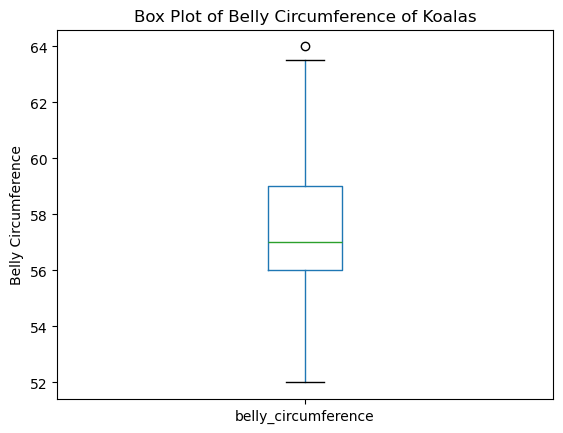

In [87]:
clean_df1.boxplot(column='belly_circumference')

plt.grid(False)
plt.title('Box Plot of Belly Circumference of Koalas')
plt.ylabel('Belly Circumference')
plt.show()

In [89]:
Q1 = clean_df1['belly_circumference'].quantile(0.25)
Q3 = clean_df1['belly_circumference'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

clean_df1 = clean_df1[(clean_df1['belly_circumference'] >= lower_bound) & (clean_df1['belly_circumference'] <= upper_bound)]

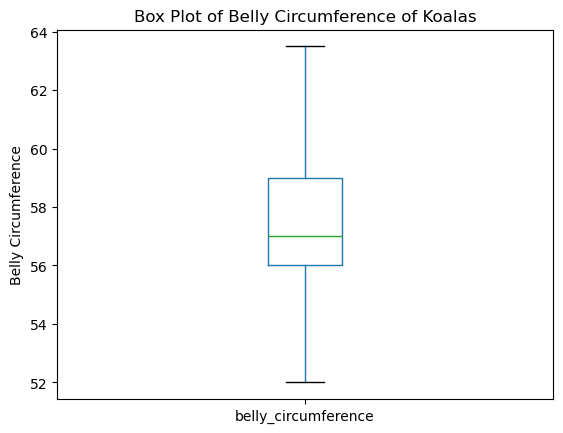

In [91]:
clean_df1.boxplot(column='belly_circumference')

plt.grid(False)
plt.title('Box Plot of Belly Circumference of Koalas')
plt.ylabel('Belly Circumference')
plt.show()

In [93]:
size = len(clean_df1)
print('The length of the database is', size)

The length of the database is 79


In [95]:
clean_df1.head(20)

,koala_id,region,habitat,gender,age_in_years,Paw Size,total_length,head_length,ear_size,foot_length,skull_width,eye_diameter,chest_circumference,belly_circumference
0,1,1,VIC,Male,8.0,16.0,77.0,19.1,19.5,24.5,15.4,2.2,63.0,61.0
1,2,1,VIC,Female,6.0,16.5,79.5,17.5,16.2,22.5,12.6,3.0,63.5,58.0
3,4,1,VIC,Female,6.0,18.0,80.0,18.2,17.2,26.1,12.1,2.2,63.0,59.0
4,5,1,VIC,Female,2.0,16.0,73.5,16.5,18.2,21.0,11.3,2.1,63.5,58.0
5,6,1,VIC,Female,1.0,15.5,78.5,18.1,18.6,23.2,9.8,1.2,65.0,57.0
6,7,1,VIC,Male,2.0,16.0,77.5,20.3,17.0,21.5,13.2,1.2,65.0,59.5
7,8,1,VIC,Female,6.0,17.0,79.0,19.8,18.9,22.7,12.6,1.5,64.0,59.0
8,9,1,VIC,Female,9.0,17.0,79.5,18.4,17.9,22.4,11.3,2.5,63.0,58.0
9,10,1,VIC,Female,6.0,17.5,77.5,16.8,18.4,20.9,13.0,1.4,62.5,57.0
10,11,1,VIC,Female,9.0,19.0,77.5,18.3,16.3,27.2,12.2,1.9,66.0,59.0


## Visualization of Data ##

### Comparison of sizes of Koala based on habitat and region ###

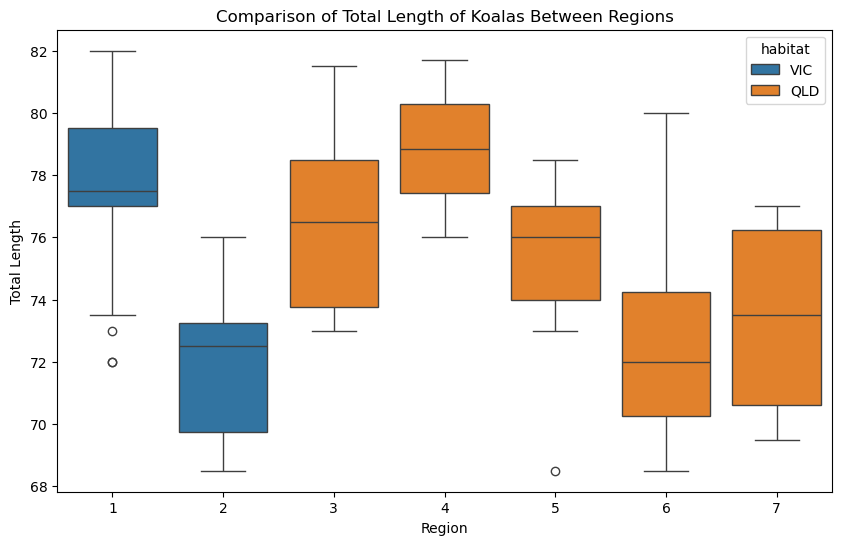

In [99]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='region', y='total_length', hue='habitat', data=clean_df1)

plt.title('Comparison of Total Length of Koalas Between Regions')
plt.xlabel('Region')
plt.ylabel('Total Length')

plt.show()

### Relationship between age of a koala and paw size ###

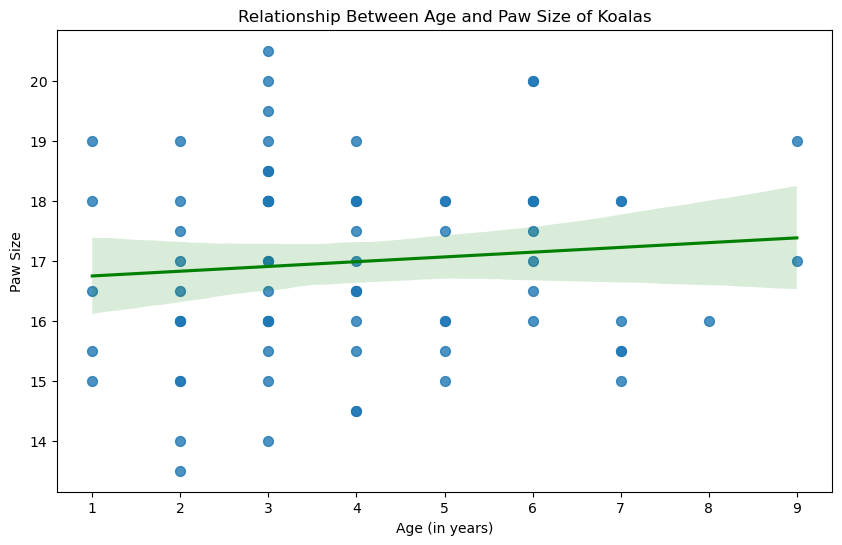

In [102]:
plt.figure(figsize=(10, 6))

sns.regplot(x='age_in_years', y='Paw Size', data=clean_df1, scatter_kws={'s':50}, line_kws={"color": "green"})

plt.title('Relationship Between Age and Paw Size of Koalas')
plt.xlabel('Age (in years)')
plt.ylabel('Paw Size')

plt.show()

## Section 3: Analysis ##

### Part 1: Determining the mean head length of koalas ###

We have to determine whether the mean headlength of koalas is significantly different than 92.0 mm. For which, we need to use T-test to determine whether the claim is true or false.

In [107]:
head_length = clean_df1['head_length']

t_stat, p_value = stats.ttest_1samp(head_length, 92.0)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")


T-statistic: -242.53623657267866
P-value: 5.145757156187884e-114


### Part 2: Determining whether male and female koalas have different head length ###

In [110]:
female_head_length = clean_df1[clean_df1['gender'] == 'Female']['head_length']
male_head_length = clean_df1[clean_df1['gender'] == 'Male']['head_length']

t_stat, p_value = stats.ttest_ind(female_head_length, male_head_length)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

T-statistic: -1.2231055502779669
P-value: 0.22501997457012562


### Part 3: Determining the total length of koala based on its head length ###

In [113]:
X = clean_df1[['head_length']] 
y = clean_df1['total_length']  


In [115]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [117]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Coefficient (slope): {model.coef_[0]}")
print(f"Intercept: {model.intercept_}")

Coefficient (slope): 0.7155000342703546
Intercept: 62.77314145908268


In [119]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Print the accuracy metrics
print(f"R-squared: {r2}")
print(f"Mean Squared Error: {mse}")

R-squared: 0.25201367267078834
Mean Squared Error: 9.547782504414185


In [121]:
new_head_lengths = np.array([[20.0], [21.5], [22.0], [19.5], [18.5]])  # Example new head lengths
predicted_total_lengths = model.predict(new_head_lengths)

for head_length, total_length in zip(new_head_lengths, predicted_total_lengths):
    print(f"Predicted total length for head length {head_length[0]} mm: {total_length:.2f} mm")

Predicted total length for head length 20.0 mm: 77.08 mm
Predicted total length for head length 21.5 mm: 78.16 mm
Predicted total length for head length 22.0 mm: 78.51 mm
Predicted total length for head length 19.5 mm: 76.73 mm
Predicted total length for head length 18.5 mm: 76.01 mm


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


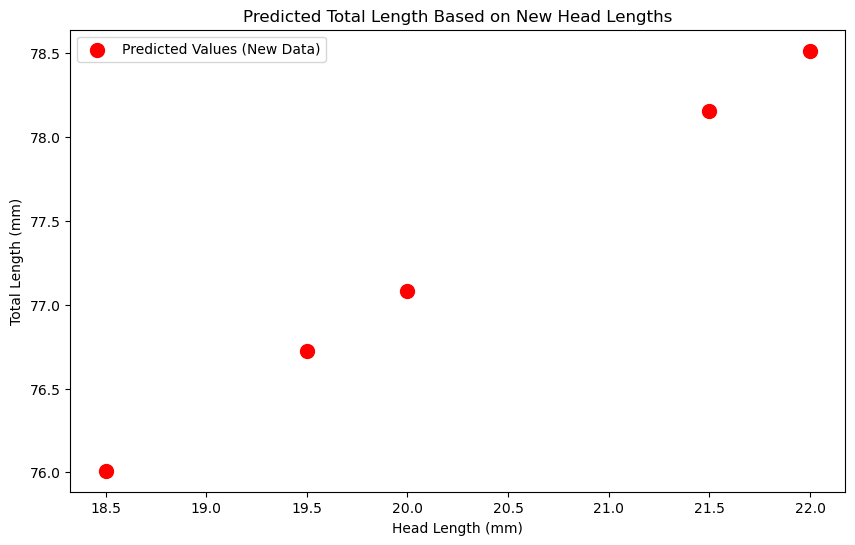

In [123]:
plt.figure(figsize=(10, 6))

plt.scatter(new_head_lengths, predicted_total_lengths, color='red', label='Predicted Values (New Data)', marker='o', s=100)

plt.xlabel('Head Length (mm)')
plt.ylabel('Total Length (mm)')
plt.title('Predicted Total Length Based on New Head Lengths')

plt.legend()
plt.show()

### Part 4: Predict the total length of a Koala based on multiple factors such as head length, skull width, and foot length ####

In [126]:
X = clean_df1[['head_length', 'skull_width', 'foot_length']] 
y = clean_df1['total_length']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Coefficient (slope): {model.coef_[0]}")
print(f"Intercept: {model.intercept_}")

Coefficient (slope): 0.383054049032653
Intercept: 60.34211782613602


In [128]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Print the accuracy metrics
print(f"R-squared: {r2}")
print(f"Mean Squared Error: {mse}")

R-squared: 0.18645663537762036
Mean Squared Error: 10.384595038065552


### Part 5: Do environmental factors such as state affect Koala’s physical characteristics? ###

In [139]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('total_length ~ C(region)', data=clean_df1).fit()  
# 'C(region)' treats region as a categorical variable
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

               sum_sq    df        F    PR(>F)
C(region)  361.343901   6.0  7.19232  0.000005
Residual   602.882935  72.0      NaN       NaN


In [137]:
X = clean_df1[['head_length', 'skull_width', 'foot_length']]  
y = clean_df1['total_length']    
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")
print(f"R-squared: {r2_score(y_test, y_pred)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")

Coefficients: [0.38305405 0.40504587 0.20405662]
Intercept: 60.34211782613602
R-squared: 0.18645663537762036
Mean Squared Error: 10.384595038065552
